In [1]:
# ============================================================================
# CELL 0: Install Library (If using VSCode)
# ============================================================================

# 1. Masuk Terminal
# 2. Buat .venv
    # python -m venv .venv
# 3. Aktifkan
    # .venv\Scripts\activate        # Windows
    # source .venv/bin/activate     # Mac/Linux
# 4. Install library
    # pip install -r requirements.txt
# 5. Run kode

In [2]:
# ============================================================================
# CELL 1: Initiate Kaggle Default libraries. (DO NOT TOUCH)
# ============================================================================

# For this case, the dataset we need is a "tech-mental-health-burnout-dataset"
# (or adjust to the actual dataset name on Kaggle)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

import warnings
warnings.filterwarnings('ignore')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        print("Dataset ditemukan di:", file_path)

In [3]:
# ============================================================================
# CELL 2.1: Load Data & Pre-EDA Data Cleaning
# ============================================================================

DATASET_PATH = '../mental_health_burnout_tech_2026.csv'  # Sesuaikan path ini
df = pd.read_csv(DATASET_PATH)

# --- DROP KOLOM IDENTITAS ---
df = df.drop(columns=['employee_id'])

# --- DROP KOLOM CIRCULAR & REDUNDAN ---
# burnout_score  : sumber dari burnout_level > circular jika dipakai sebagai fitur
# phq9_category  : versi teks dari phq9_score > redundan
# gad7_category  : versi teks dari gad7_score > redundan
df = df.drop(columns=['burnout_score', 'phq9_category', 'gad7_category'])

# --- TARGET: burnout_level ---
# Berbeda dari dataset sebelumnya, di sini label Low/Moderate/High/Severe
# SUDAH ADA langsung di dataset. Tidak perlu pd.qcut sama sekali.
# burnout_level langsung kita pakai sebagai target klasifikasi.
print("="*70)
print(" KOLOM 'employee_id' TELAH DIHAPUS.")
print(" KOLOM 'burnout_score', 'phq9_category', 'gad7_category' TELAH DIHAPUS.")
print(f" TARGET: 'burnout_level' dengan nilai unik: {sorted(df['burnout_level'].unique())}")
print("="*70 + "\n")
print(df.info())
display(df.head(3))

 KOLOM 'employee_id' TELAH DIHAPUS.
 KOLOM 'burnout_score', 'phq9_category', 'gad7_category' TELAH DIHAPUS.
 TARGET: 'burnout_level' dengan nilai unik: ['High', 'Low', 'Moderate', 'Severe']

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   country                      100000 non-null  str    
 3   job_role                     100000 non-null  str    
 4   seniority_level              100000 non-null  str    
 5   years_experience             100000 non-null  int64  
 6   years_at_company             100000 non-null  float64
 7   company_size                 100000 non-null  str    
 8   industry                     100000 non-null  str    
 9   work_mode                    100000 non-null  str    
 1

,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,work_mode,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,phq9_score,gad7_score,burnout_level,seeks_mental_health_support,job_change_intention
0,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,Remote,...,2.8,3.9,8.3,6.1,10.0,19,12,Severe,1,1
1,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,Hybrid,...,3.7,3.8,9.3,5.4,9.3,8,6,High,1,1
2,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,On-site,...,4.8,5.7,8.9,4.1,8.9,8,9,Severe,0,1


In [4]:
# ============================================================================
# CELL 3.1: Data Overview - Missing Values & Duplicates & Class Distribution
# ============================================================================

print("--- CEK MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- CEK DUPLIKAT ---")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

print(f"\n--- DISTRIBUSI BURNOUT CATEGORY ---")
urutan = ['Low', 'Moderate', 'High', 'Severe']
urutan_ada = [x for x in urutan if x in df['burnout_level'].unique()]
print(df['burnout_level'].value_counts().reindex(urutan_ada))

print(f"\n--- PERSENTASE DISTRIBUSI ---")
print(df['burnout_level'].value_counts(normalize=True).reindex(urutan_ada) * 100)

# Catatan: kalau distribusinya tidak seimbang, catat di sini untuk
# ditangani saat training (class_weight atau sample_weight).

--- CEK MISSING VALUES ---
age                            0
gender                         0
country                        0
job_role                       0
seniority_level                0
years_experience               0
years_at_company               0
company_size                   0
industry                       0
work_mode                      0
salary_usd                     0
work_hours_per_week            0
meetings_per_day               0
team_size                      0
sleep_hours_per_night          0
exercise_days_per_week         0
vacation_days_taken            0
therapy_access                 0
uses_therapy                   0
ai_tools_daily                 0
manager_support_score          0
work_life_balance_score        0
job_satisfaction_score         0
social_support_score           0
deadline_pressure_score        0
autonomy_score                 0
stress_score                   0
phq9_score                     0
gad7_score                     0
burnout_level   

In [5]:
# ============================================================================
# CELL 3.2: Data Overview - Basic Info
# ============================================================================

print("--- TAMPILAN 5 DATA PERTAMA ---")
display(df.head())

print("\n--- INFORMASI TIPE DATA & JUMLAH BARIS ---")
display(df.info())

print("\n--- STATISTIK DESKRIPTIF (Kolom Numerik) ---")
display(df.describe())

print("\n--- STATISTIK DESKRIPTIF (Kolom Kategorikal) ---")
display(df.describe(include=['object', 'category']))


--- TAMPILAN 5 DATA PERTAMA ---


,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,work_mode,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,phq9_score,gad7_score,burnout_level,seeks_mental_health_support,job_change_intention
0,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,Remote,...,2.8,3.9,8.3,6.1,10.0,19,12,Severe,1,1
1,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,Hybrid,...,3.7,3.8,9.3,5.4,9.3,8,6,High,1,1
2,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,On-site,...,4.8,5.7,8.9,4.1,8.9,8,9,Severe,0,1
3,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,Remote,...,5.0,4.8,6.2,7.3,10.0,14,11,Severe,0,1
4,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,Hybrid,...,1.0,4.4,5.4,4.4,7.7,8,0,Moderate,1,0



--- INFORMASI TIPE DATA & JUMLAH BARIS ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   country                      100000 non-null  str    
 3   job_role                     100000 non-null  str    
 4   seniority_level              100000 non-null  str    
 5   years_experience             100000 non-null  int64  
 6   years_at_company             100000 non-null  float64
 7   company_size                 100000 non-null  str    
 8   industry                     100000 non-null  str    
 9   work_mode                    100000 non-null  str    
 10  salary_usd                   100000 non-null  int64  
 11  work_hours_per_week          100000 non-null  int64  
 12  meetings_per_day          

None


--- STATISTIK DESKRIPTIF (Kolom Numerik) ---


,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,vacation_days_taken,...,work_life_balance_score,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,12.049800,...,5.422584,4.834823,5.383951,6.385095,5.836528,7.055399,6.27194,5.118920,0.497890,0.320020
std,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,5.878482,...,1.808319,1.920796,1.832774,1.769242,1.836491,2.128530,4.95427,4.007513,0.499998,0.466486
min,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000
25%,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,8.000000,...,4.200000,3.500000,4.100000,5.200000,4.600000,5.500000,2.00000,2.000000,0.000000,0.000000
50%,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,12.000000,...,5.400000,4.800000,5.400000,6.400000,5.800000,7.100000,6.00000,5.000000,0.000000,0.000000
75%,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,16.000000,...,6.700000,6.200000,6.600000,7.600000,7.100000,8.900000,10.00000,8.000000,1.000000,1.000000
max,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,30.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000



--- STATISTIK DESKRIPTIF (Kolom Kategorikal) ---


,gender,country,job_role,seniority_level,company_size,industry,work_mode,burnout_level
count,100000,100000,100000,100000,100000,100000,100000,100000
unique,4,10,12,6,5,10,3,4
top,Male,USA,Software Engineer,Mid,Mid (201-1000),SaaS / Cloud,Hybrid,Severe
freq,65243,31966,20080,28092,25062,19957,39856,28576


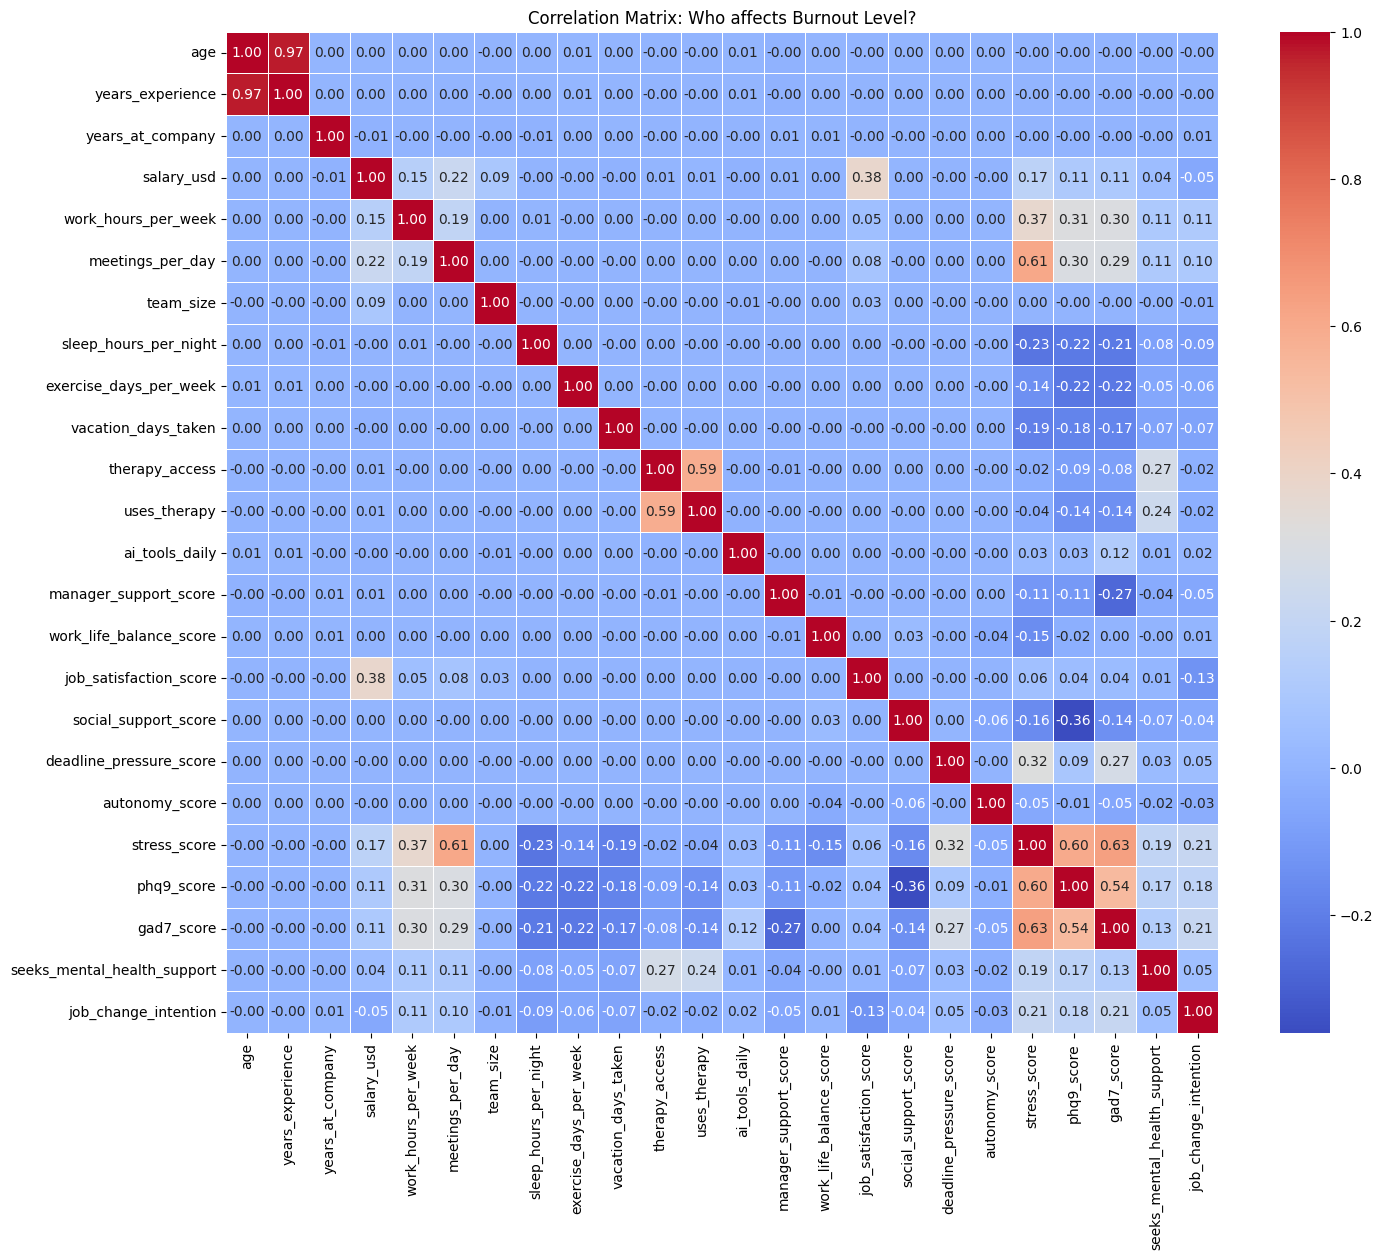

In [6]:
# ============================================================================
# CELL 4.1: Exploratory Data Analysis (EDA) - Correlation Matrix
# ============================================================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(16, 13))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Matrix: Who affects Burnout Level?')
plt.savefig('../graphs_init/viz_init_01a_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Correlation Matrix (Exploratory Data Analysis)

**1. Multikolinearitas Kritis: age vs years_experience**<br>
`age` dan `years_experience` memiliki korelasi **+0.97** hampir identik secara
informasi. Semakin tua seseorang, semakin banyak pengalaman kerjanya, sehingga
kedua kolom ini mengukur hal yang hampir sama. Menyertakan keduanya sekaligus
berisiko menyebabkan redundansi dalam model. **Keputusan: drop `age`,
pertahankan `years_experience`** karena pengalaman kerja lebih relevan
terhadap dinamika burnout dibanding usia semata.

**2. Kluster Mental Health: stress, PHQ-9, GAD-7**<br>
`stress_score`, `phq9_score`, dan `gad7_score` saling berkorelasi moderat
(stress–phq9: **+0.60**, stress–gad7: **+0.63**, phq9–gad7: **+0.54**).
Ketiga fitur ini mengukur konstruk psikologis yang memang saling terkait
stres tinggi cenderung memunculkan gejala depresi (PHQ-9) dan kecemasan
(GAD-7). Korelasi di kisaran 0.54–0.63 masih dalam batas wajar dan tidak
dianggap multikolinearitas bermasalah. **Keputusan: `stress_score` akan
di-drop karena korelasinya dengan target (0.81) terlalu dominan;
`phq9_score` dan `gad7_score` dipertahankan** sebagai instrumen klinis
tervalidasi.

**3. Beban Kerja Saling Terkait**<br>
`work_hours_per_week` dan `meetings_per_day` berkorelasi **+0.19** lemah
tapi logis. Karyawan dengan jam kerja panjang cenderung mengikuti lebih
banyak meeting. Tidak ada masalah multikolinearitas di sini, keduanya tetap
memberikan informasi yang berbeda dan dapat dipertahankan.

**4. Akses dan Penggunaan Terapi**<br>
`therapy_access` dan `uses_therapy` berkorelasi **+0.59**. Wajar: yang punya
akses lebih mungkin menggunakannya. Namun keduanya mengukur hal berbeda
akses adalah fasilitas, penggunaan adalah perilaku. Keduanya dipertahankan.

**5. Dukungan Sosial sebagai Penyeimbang Stres**<br>
`social_support_score` berkorelasi negatif dengan `phq9_score` (**-0.36**)
dan `stress_score` (**-0.16**), konsisten dengan penelitian psikologi: semakin
tinggi dukungan sosial, semakin rendah gejala depresi dan stres yang dialami.

**6. Mayoritas Fitur Independen**<br>
Sebagian besar pasangan fitur lainnya menunjukkan korelasi di bawah 0.15,
mengindikasikan tidak ada masalah multikolinearitas sistemik selain yang
sudah disebutkan di atas. Ini kondisi yang sehat untuk model machine learning.

--- KORELASI FITUR NUMERIK vs burnout_level ---
stress_score                   0.813147
gad7_score                     0.686289
phq9_score                     0.684914
work_hours_per_week            0.442634
meetings_per_day               0.425740
sleep_hours_per_night         -0.311382
vacation_days_taken           -0.258624
job_change_intention           0.239248
seeks_mental_health_support    0.206469
social_support_score          -0.203115
exercise_days_per_week        -0.191000
manager_support_score         -0.153507
salary_usd                     0.152888
deadline_pressure_score        0.131391
autonomy_score                -0.078655
job_satisfaction_score         0.054433
uses_therapy                  -0.050905
ai_tools_daily                 0.043489
therapy_access                -0.032746
years_experience              -0.003087
years_at_company              -0.003033
age                           -0.002815
work_life_balance_score        0.000802
team_size                      0

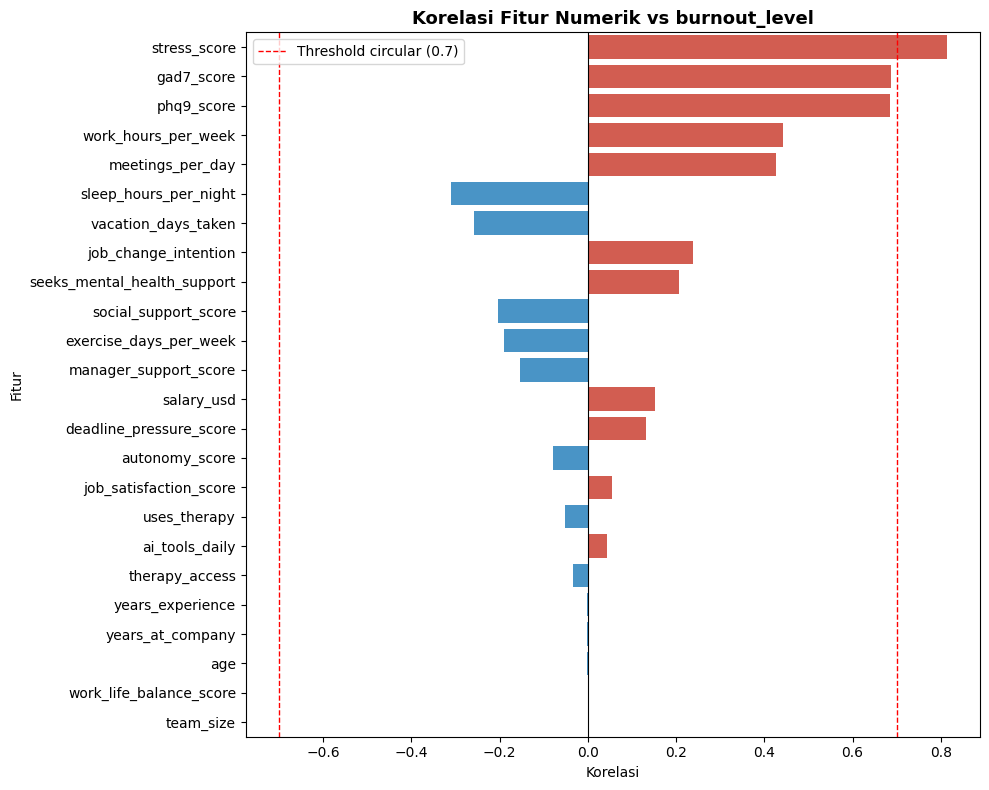

In [7]:
# ============================================================================
# CELL 4.1 (continued): Cek korelasi fitur vs burnout_level
# ============================================================================

# Encode burnout_level sebagai ordinal untuk bisa masuk korelasi
urutan_level = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
df_corr_check = df.copy()
df_corr_check['burnout_level_num'] = df['burnout_level'].map(urutan_level)

korelasi_ke_target = (
    df_corr_check[num_cols + ['burnout_level_num']]
    .corr()['burnout_level_num']
    .drop('burnout_level_num')
    .sort_values(key=abs, ascending=False)
)

print("--- KORELASI FITUR NUMERIK vs burnout_level ---")
print(korelasi_ke_target)
print("\n--- CEK KHUSUS: stress_score ---")
print(f"Korelasi stress_score vs burnout_level : {korelasi_ke_target['stress_score']:.4f}")
print(f"Korelasi stress_score vs phq9_score    : {df[['stress_score','phq9_score']].corr().iloc[0,1]:.4f}")
print("\nJika korelasi stress_score > 0.7, pertimbangkan untuk di-drop (terlalu circular).")

# Visualisasi korelasi fitur vs burnout_level
plt.figure(figsize=(10, 8))
warna = ['#e74c3c' if v > 0 else '#3498db' for v in korelasi_ke_target.values]
sns.barplot(
    x=korelasi_ke_target.values,
    y=korelasi_ke_target.index,
    palette=warna
)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.7,  color='red',   linewidth=1, linestyle='--', label='Threshold circular (0.7)')
plt.axvline(x=-0.7, color='red',   linewidth=1, linestyle='--')
plt.title('Korelasi Fitur Numerik vs burnout_level', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi')
plt.ylabel('Fitur')
plt.legend()
plt.tight_layout()
plt.savefig('../graphs_init/viz_init_01b_correlation_to_target.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Korelasi Fitur Numerik vs burnout_level

**1. stress_score (0.813): Akan Di-drop**<br>
Korelasi tertinggi terhadap `burnout_level`. Meski stres dan burnout memang
berkaitan secara psikologis, nilai 0.81 terlalu tinggi dan berisiko
mendominasi model seperti `fatigue_score` pada dataset sebelumnya. Dengan
`phq9_score` dan `gad7_score` yang sudah mencakup konstruk serupa secara
lebih terstandar, `stress_score` diputuskan untuk **di-drop**.

**2. PHQ-9 dan GAD-7 (0.684–0.686): Fitur Unggulan**<br>
`phq9_score` dan `gad7_score` sama-sama berkorelasi kuat dengan `burnout_level`
dengan nilai yang hampir identik (~0.685). Keduanya merupakan instrumen skrining
klinis tervalidasi secara internasional yang memang dirancang untuk mengukur
kondisi mental yang berkaitan erat dengan burnout. Ini adalah sinyal terkuat
yang dapat dipertanggungjawabkan secara ilmiah dalam dataset ini.

**3. Beban Kerja (0.426–0.443): Fitur Behavioral Terkuat**<br>
`work_hours_per_week` (+0.443) dan `meetings_per_day` (+0.426) menunjukkan
korelasi yang bermakna: semakin tinggi beban kerja kuantitatif, semakin
tinggi risiko burnout. Temuan ini konsisten dengan literatur occupational
health dan menjadikan keduanya fitur behavioral paling informatif dalam
dataset ini.

**4. Tidur dan Recovery (-0.191 hingga -0.311): Faktor Protektif**<br>
`sleep_hours_per_night` (-0.311), `vacation_days_taken` (-0.259), dan
`exercise_days_per_week` (-0.191) semuanya berkorelasi negatif semakin
baik kualitas recovery seseorang, semakin rendah burnout-nya. Pola ini
sangat konsisten dengan teori Conservation of Resources (COR) dalam
psikologi kerja.

**5. Dukungan Lingkungan (-0.154 hingga -0.203)**<br>
`social_support_score` (-0.203) dan `manager_support_score` (-0.154)
keduanya negatif terhadap burnout. Dukungan dari rekan kerja dan atasan
terbukti berperan sebagai buffer terhadap burnout temuan yang sejalan
dengan penelitian Maslach et al. mengenai dimensi burnout di tempat kerja.

**6. job_change_intention dan seeks_mental_health_support: Efek, Bukan Penyebab**<br>
Keduanya berkorelasi positif dengan burnout (0.239 dan 0.206), namun perlu
dicatat bahwa ini kemungkinan merupakan **akibat** dari burnout, bukan
penyebabnya. Orang yang sudah burnout lebih cenderung ingin ganti kerja dan
mencari bantuan mental. Memasukkan keduanya sebagai fitur berisiko membuat
model belajar hubungan yang terbalik secara kausal. **Keputusan: di-drop.**

**7. Fitur dengan Sinyal Sangat Lemah (<0.05)**<br>
`age`, `years_experience`, `years_at_company`, `team_size`,
`work_life_balance_score`, `therapy_access`, dan `ai_tools_daily` semuanya
menunjukkan korelasi di bawah 0.05 terhadap `burnout_level`. Fitur-fitur
ini memberikan kontribusi minimal terhadap prediksi dan dapat
dipertimbangkan untuk di-drop pada tahap feature selection selanjutnya.

--- HISTOGRAM FITUR NUMERIK ---


KeyboardInterrupt: 

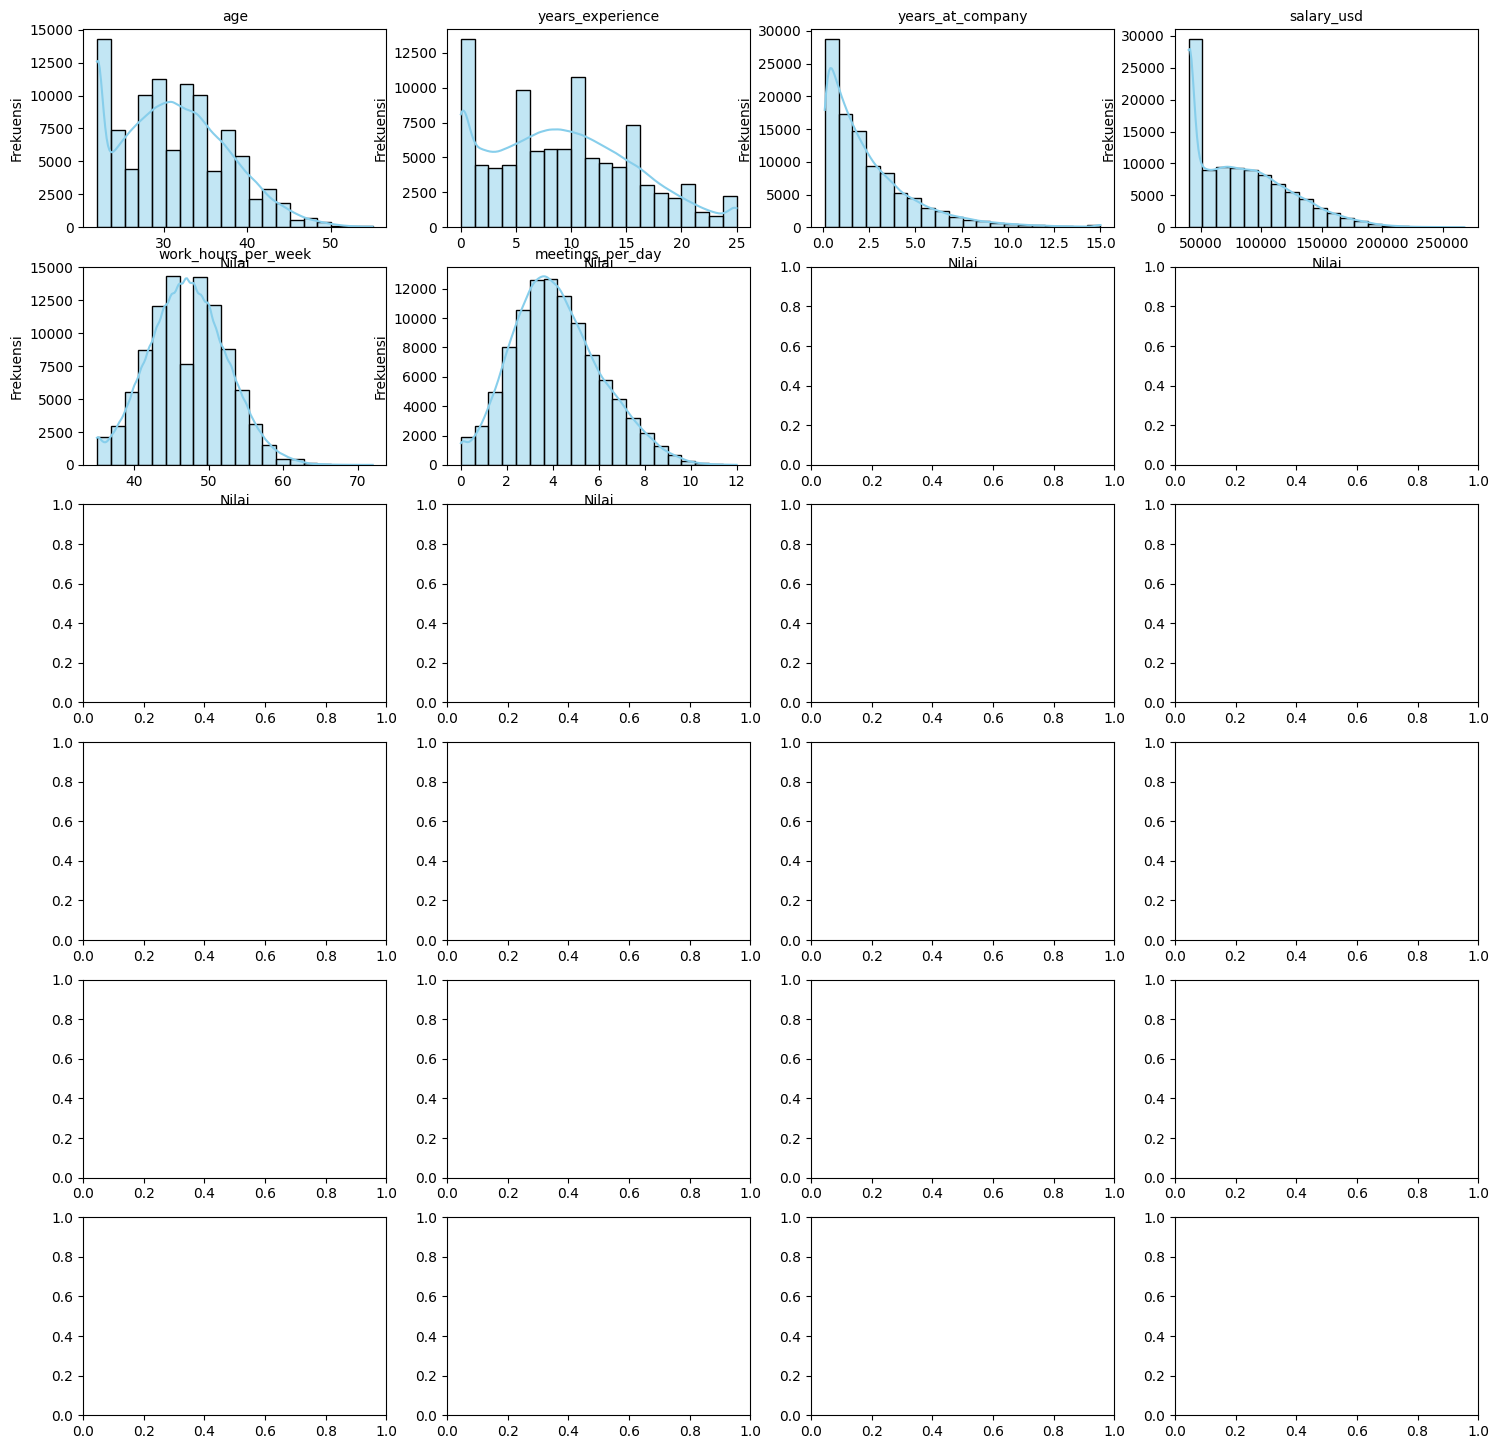

In [8]:
# ============================================================================
# CELL 4.2: Exploratory Data Analysis (EDA) - Histogram
# ============================================================================

# ============================================================
# BAGIAN A: Fitur Numerik
# ============================================================
print("--- HISTOGRAM FITUR NUMERIK ---")

n_cols_grid = 4
n_rows_grid = math.ceil(len(num_cols) / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, n_rows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Kolom dengan sedikit nilai unik (binary/integer kecil) → countplot
    if len(df[col].unique()) <= 10:
        sns.countplot(x=df[col], color='skyblue', edgecolor='black', ax=axes[i])
    else:
        sns.histplot(df[col], bins=20, color='skyblue', edgecolor='black', kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../graphs_init/viz_init_02a_histogram_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# BAGIAN B: Fitur Kategorikal
# ============================================================
print("\n--- DISTRIBUSI FITUR KATEGORIKAL ---")

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'burnout_level']  # target dipisah ke Bagian C

n_cols_grid = 3
n_rows_grid = math.ceil(len(cat_cols) / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, n_rows_grid * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    nilai = df[col].value_counts()
    sns.barplot(x=nilai.values, y=nilai.index, color='steelblue', edgecolor='black', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Jumlah')
    axes[i].set_ylabel('')
    for container in axes[i].containers:
        axes[i].bar_label(container, fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../graphs_init/viz_init_02b_histogram_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# BAGIAN C: Target: burnout_level
# ============================================================
print("\n--- DISTRIBUSI TARGET: burnout_level ---")

urutan     = ['Low', 'Moderate', 'High', 'Severe']
urutan_ada = [x for x in urutan if x in df['burnout_level'].unique()]
warna      = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
warna_ada  = warna[:len(urutan_ada)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(
    x=df['burnout_level'],
    order=urutan_ada,
    palette=dict(zip(urutan_ada, warna_ada)),
    edgecolor='black',
    ax=axes[0]
)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold',
                      label_type='center', color='white')
axes[0].set_title('Distribusi burnout_level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah')

# Pie chart
nilai_level = df['burnout_level'].value_counts().reindex(urutan_ada)
axes[1].pie(
    nilai_level,
    labels=nilai_level.index,
    colors=warna_ada,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('burnout_level (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../graphs_init/viz_init_02c_burnout_level_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Histogram Distribusi Fitur (Exploratory Data Analysis)

**A. Fitur Numerik**

**1. stress_score: Konfirmasi Drop**<br>
Distribusi `stress_score` sangat miring kiri dengan mayoritas data menumpuk
di nilai 8–10. Pola ekstrem ini tidak natural dan memperkuat keputusan untuk
**men-drop kolom ini** sebelum training.

**2. PHQ-9 dan GAD-7: Distribusi Bimodal**<br>
Keduanya menunjukkan pola bimodal: lonjakan besar di nilai 0, lalu cluster
kedua di kisaran 10–15 (PHQ-9) dan 8–14 (GAD-7). Ini mengindikasikan
adanya dua subkelompok yang berbeda, responden tanpa gejala sama sekali
vs. responden dengan gejala moderat hingga berat.

**3. years_at_company dan salary_usd: Right-Skewed**<br>
Mayoritas karyawan baru bergabung (<3 tahun) dan bergaji di rentang bawah.
Kedua fitur ini perlu dipertimbangkan untuk transformasi log bila model
sensitif terhadap skewness.

**4. therapy_access dan uses_therapy: Imbalance Binary**<br>
Hanya ~35% punya akses terapi dan ~17% yang benar-benar menggunakannya.
Ketimpangan ini wajar secara konteks, namun perlu dicatat bahwa kedua
fitur ini akan memiliki pengaruh terbatas pada model.

---

**B. Fitur Kategorikal**

**1. Gender dan Country: Tidak Seimbang**<br>
`gender` didominasi Male (~65%) dan `country` didominasi USA (~32%).
Dataset ini tidak merepresentasikan populasi global secara merata,
perlu dicatat sebagai limitasi model.

**2. Fitur Lain Cukup Seimbang**<br>
`seniority_level`, `company_size`, `industry`, dan `work_mode` semuanya
menunjukkan distribusi yang cukup merata. Tidak ada kelas yang terlalu
dominan sehingga tidak menimbulkan masalah berarti.

---

**C. Target: burnout_level**

Distribusi cukup seimbang: Low (25.8%), Moderate (26.3%),
High (19.4%), Severe (28.6%). Kelas `High` sedikit lebih sedikit (~19%),
namun perbedaannya tidak ekstrem. Dataset ini **tidak memerlukan
resampling berat** cukup gunakan `class_weight='balanced'`
saat training sebagai langkah pencegahan.

--- BOXPLOT FITUR NUMERIK ---


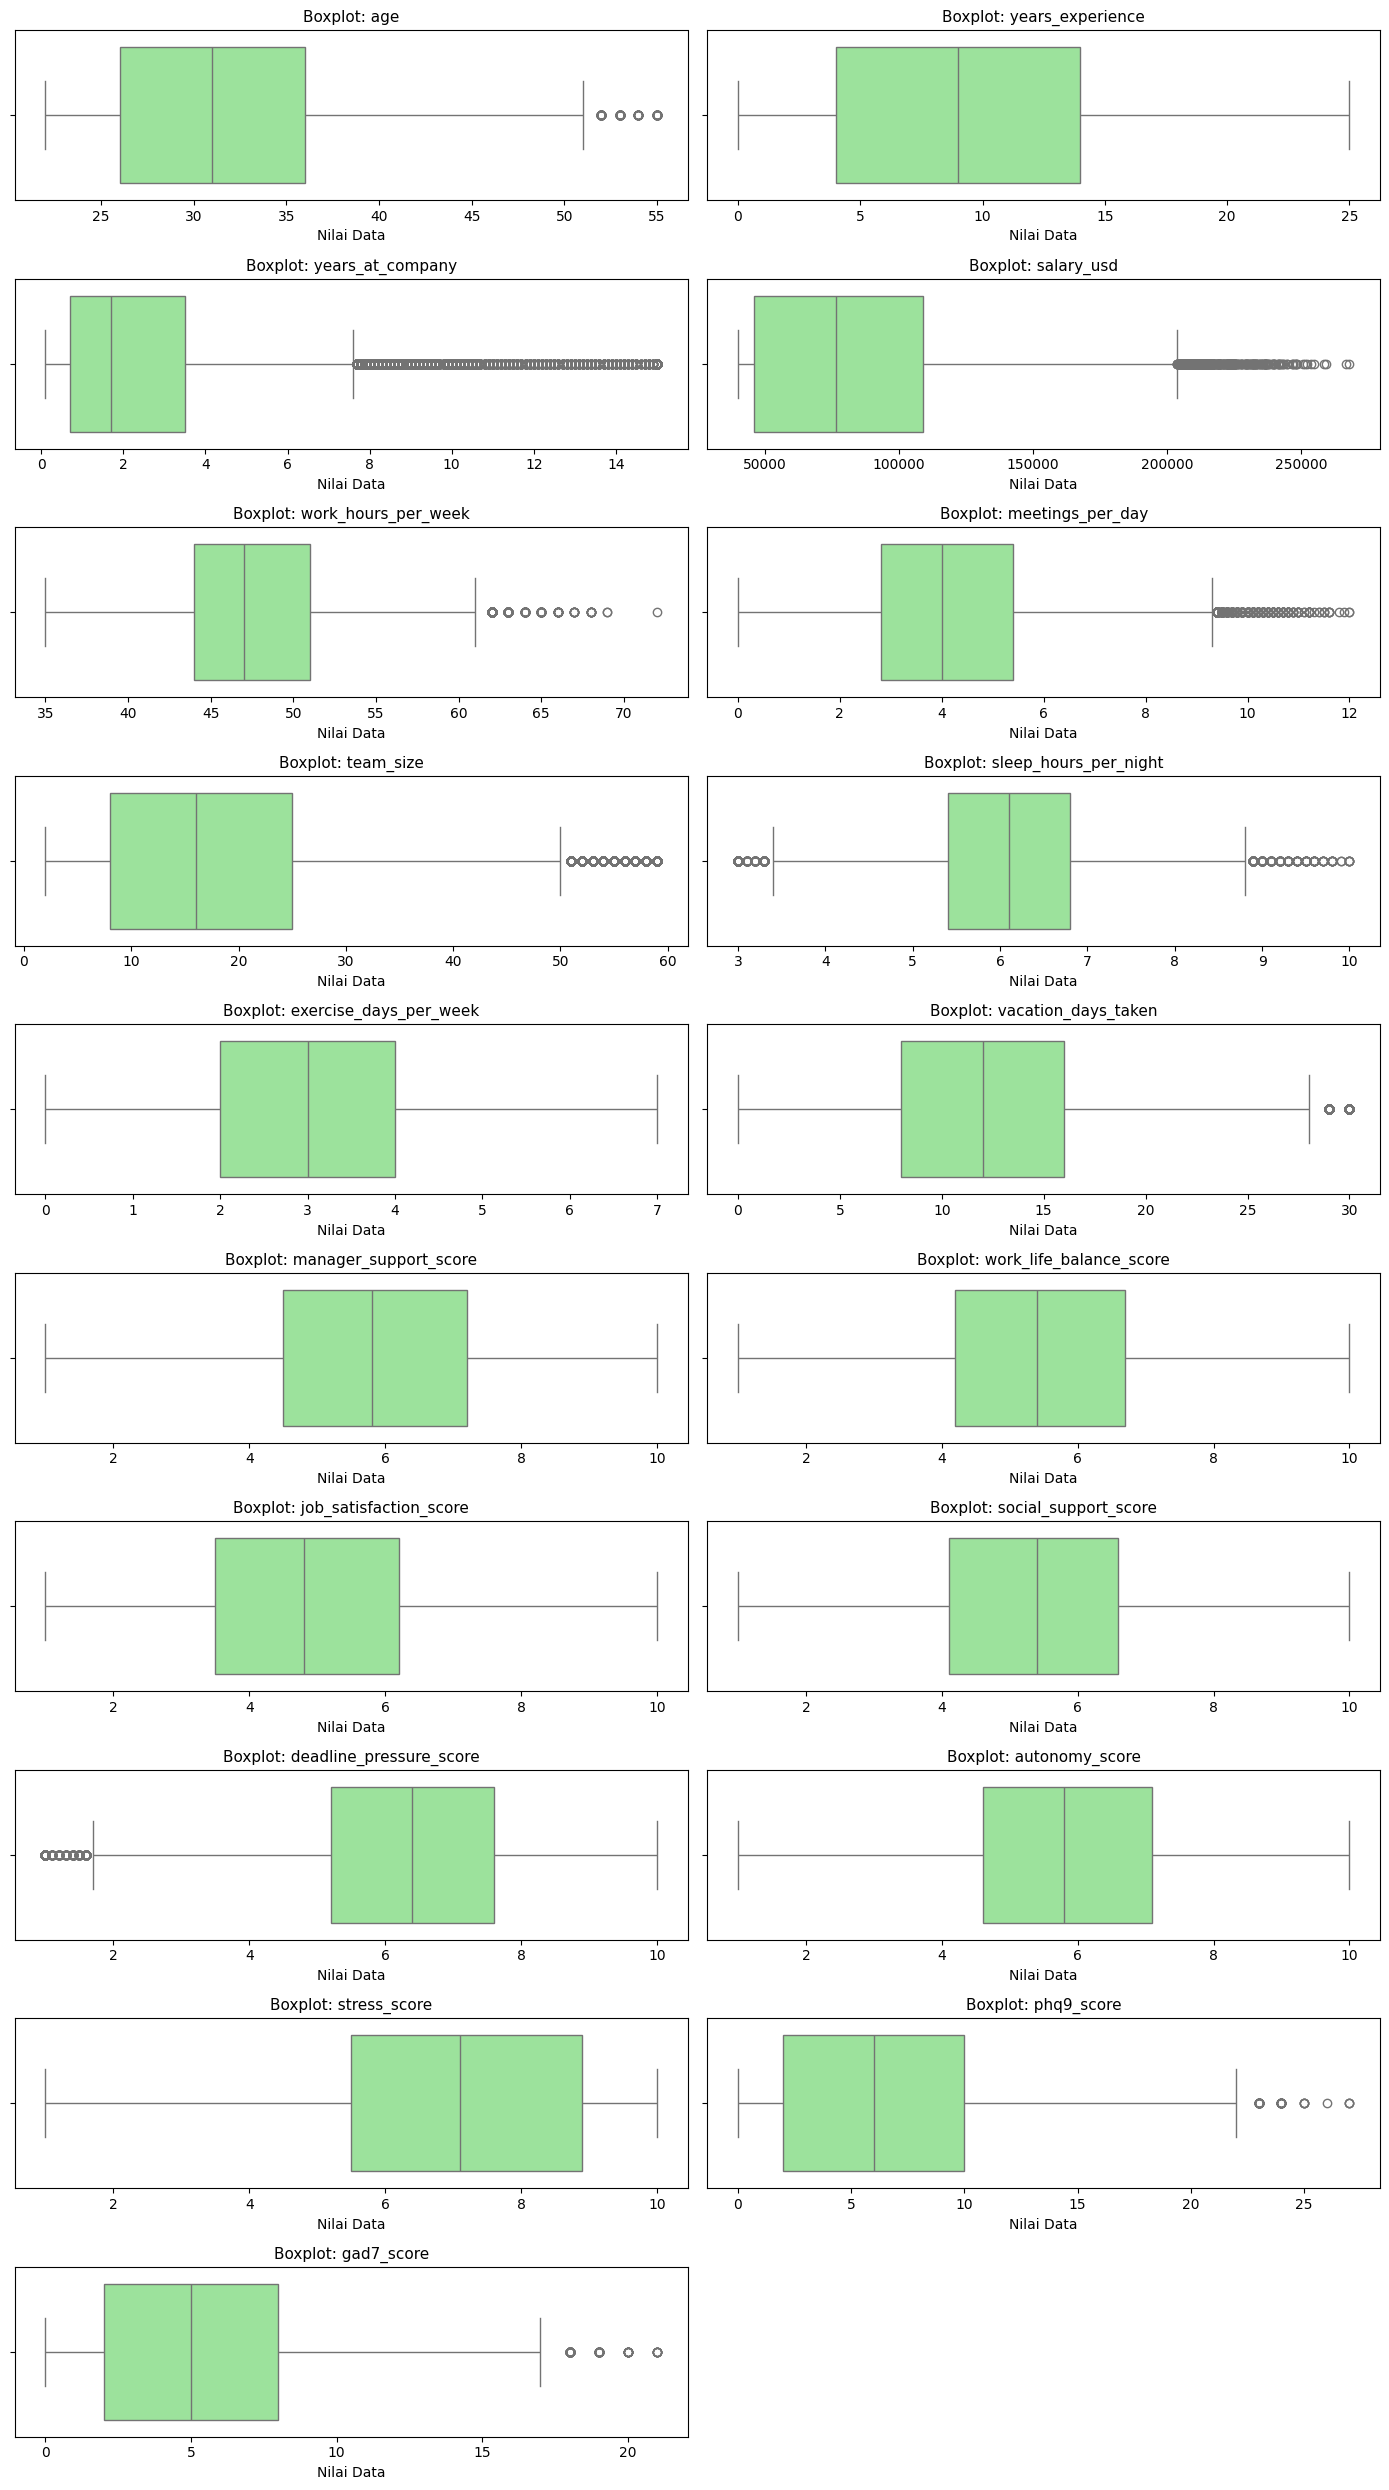

In [ ]:
# ============================================================================
# CELL 4.3: Exploratory Data Analysis (EDA) - Boxplot
# ============================================================================

print("--- BOXPLOT FITUR NUMERIK ---")

# Kolom binary tidak ideal untuk boxplot (nilainya hanya 0 atau 1)
# Dikeluarkan dari visualisasi agar tidak menghasilkan boxplot yang kolaps
binary_cols = ['therapy_access', 'uses_therapy', 'ai_tools_daily',
               'seeks_mental_health_support', 'job_change_intention']
num_cols_box = [c for c in num_cols if c not in binary_cols]

n_cols_grid = 2
n_rows_grid = math.ceil(len(num_cols_box) / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 2.5))
axes = axes.flatten()

for i, col in enumerate(num_cols_box):
    sns.boxplot(x=df[col], orient='h', color='lightgreen', ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_xlabel('Nilai Data', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../graphs_init/viz_init_03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Boxplot Deteksi Outlier (Exploratory Data Analysis)

**Kesimpulan Umum**<br>
Fitur yang paling memerlukan perhatian outlier adalah `years_at_company`,
`meetings_per_day`, `phq9_score`, dan `salary_usd`. Skor-skor skala 1-10
(`manager_support_score`, `work_life_balance_score`, dll.) bersih dari outlier
karena memang dibatasi rentangnya.

**1. years_at_company: Outlier Ekstrem**<br>
IQR berada di 0-4 tahun, namun outlier memanjang hingga 14-15 tahun.
Mayoritas karyawan baru bergabung, tapi ada segmen kecil karyawan
sangat senior. Perlu dipertimbangkan untuk winsorizing.

**2. meetings_per_day: Outlier Kanan Banyak**<br>
Median di sekitar 4 meeting/hari dengan outlier memanjang hingga 10-12.
Karyawan dengan beban meeting sangat tinggi ini merupakan subkelompok
kecil namun berpotensi relevan terhadap burnout.

**3. salary_usd: Right-Skewed dengan Outlier**<br>
IQR di kisaran 50k-130k USD dengan outlier di 200k-250k.
Distribusi gaji yang timpang ini wajar secara konteks industri teknologi.

**4. phq9_score: Spread Sangat Lebar**<br>
IQR di 3-13, dengan outlier di 20-25 (mendekati batas maksimum 27).
Ini merepresentasikan responden dengan gejala depresi berat dan
perlu dipastikan tidak di-winsor karena nilai tinggi ini secara
klinis bermakna, bukan data error.

**5. sleep_hours_per_night: Outlier Dua Arah**<br>
Terdapat outlier di sisi kiri (sekitar 3 jam) dan kanan (9-10 jam).
Outlier kiri paling relevan mengingat korelasinya -0.31 dengan burnout.

**6. deadline_pressure_score: Outlier Kiri Tidak Biasa**<br>
Berbeda dari skor lainnya, outlier justru di sisi kiri (nilai 1-2).
Sebagian kecil karyawan nyaris tidak merasakan tekanan deadline
sama sekali, berbanding terbalik dengan mayoritas yang berada di
kisaran 5-9.

**7. Skor Skala 1-10 Lainnya: Bersih**<br>
`manager_support_score`, `work_life_balance_score`, `job_satisfaction_score`,
`social_support_score`, dan `autonomy_score` semuanya tidak menunjukkan
outlier berarti. Distribusi sehat dan siap digunakan tanpa penanganan khusus.

In [ ]:
# ============================================================================
# CELL 5: Data Cleaning - Drop Duplicates & Irrelevant Columns
# ============================================================================

baris_sebelum = df.shape[0]

print(f"Jumlah duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first')

baris_setelah = df.shape[0]
print(f"Total baris sebelum: {baris_sebelum}")
print(f"Baris dihapus      : {baris_sebelum - baris_setelah}")
print(f"Total baris setelah: {baris_setelah}\n")

# Kolom yang di-drop beserta alasannya:
# age                           : multikolinearitas 0.97 dengan years_experience
# stress_score                  : korelasi 0.81 dengan target, berisiko dominasi model
# job_change_intention          : efek dari burnout, bukan penyebab
# seeks_mental_health_support   : efek dari burnout, bukan penyebab
kolom_drop = [
    'age',
    'stress_score',
    'job_change_intention',
    'seeks_mental_health_support'
]
df = df.drop(columns=kolom_drop)

print("="*70)
print(f" KOLOM YANG DI-DROP: {kolom_drop}")
print(f" TOTAL KOLOM TERSISA: {df.shape[1]}")
print("="*70)

display(df.head())

Jumlah duplikat: 0
Total baris sebelum: 100000
Baris dihapus      : 0
Total baris setelah: 100000

 KOLOM YANG DI-DROP: ['age', 'stress_score', 'job_change_intention', 'seeks_mental_health_support']
 TOTAL KOLOM TERSISA: 28


,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,work_mode,salary_usd,...,ai_tools_daily,manager_support_score,work_life_balance_score,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,phq9_score,gad7_score,burnout_level
0,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,Remote,40000,...,0,6.0,4.4,2.8,3.9,8.3,6.1,19,12,Severe
1,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,Hybrid,131165,...,1,7.6,4.0,3.7,3.8,9.3,5.4,8,6,High
2,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,On-site,169180,...,1,4.8,6.2,4.8,5.7,8.9,4.1,8,9,Severe
3,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,Remote,147770,...,1,6.7,1.8,5.0,4.8,6.2,7.3,14,11,Severe
4,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,Hybrid,57228,...,1,7.9,5.0,1.0,4.4,5.4,4.4,8,0,Moderate


In [ ]:
# ============================================================================
# CELL 6.1: Feature Engineering & Label Encoding
# ============================================================================

df_original = df.copy()

# 1. ORDINAL ENCODING: fitur dengan urutan alami yang jelas
# seniority_level
df['seniority_level'] = df['seniority_level'].map({
    'Junior'   : 0,
    'Mid'      : 1,
    'Senior'   : 2,
    'Lead'     : 3,
    'Manager'  : 4,
    'Principal': 5
})

# company_size
df['company_size'] = df['company_size'].map({
    'Startup (1-50)'    : 0,
    'Small (51-200)'    : 1,
    'Mid (201-1000)'    : 2,
    'Large (1001-5000)' : 3,
    'Enterprise (5000+)': 4
})

# work_mode
df['work_mode'] = df['work_mode'].map({
    'On-site': 0,
    'Hybrid' : 1,
    'Remote' : 2
})

# 2. ORDINAL ENCODING: target
df['burnout_level'] = df['burnout_level'].map({
    'Low'     : 0,
    'Moderate': 1,
    'High'    : 2,
    'Severe'  : 3
})

# 3. ONE-HOT ENCODING: kolom nominal tanpa urutan alami
# gender, country, job_role, industry di-one-hot karena tidak ada
# urutan yang bisa diasumsikan antar kategorinya.
# drop_first=True untuk menghindari dummy variable trap.
df = pd.get_dummies(
    df,
    columns=['gender', 'country', 'job_role', 'industry'],
    drop_first=True,
    dtype=int
)

print("="*70)
print(" ENCODING SELESAI.")
print(f" Total kolom setelah encoding: {df.shape[1]}")
print("="*70)

display(df.head())

 ENCODING SELESAI.
 Total kolom setelah encoding: 56


,seniority_level,years_experience,years_at_company,company_size,work_mode,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,...,job_role_Software Engineer,industry_Consulting,industry_Cybersecurity,industry_E-commerce,industry_Enterprise Software,industry_Fintech,industry_Gaming,industry_Healthcare Tech,industry_SaaS / Cloud,industry_Social Media / AdTech
0,3,11,6.4,1,2,40000,55,7.3,19,6.3,...,1,0,0,0,0,0,0,1,0,0
1,4,0,5.7,0,1,131165,44,5.5,7,4.7,...,0,0,0,0,0,1,0,0,0,0
2,3,14,5.6,2,0,169180,45,6.2,27,6.0,...,1,0,0,0,0,1,0,0,0,0
3,3,14,1.2,2,2,147770,54,5.3,12,6.5,...,1,0,0,0,0,0,0,0,1,0
4,0,0,3.0,1,1,57228,49,3.9,8,7.4,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================================
# CELL 7: Train/Test Split (Preventing Data Leakage Before Norm/Standard/Transform)
# ============================================================================
from sklearn.model_selection import train_test_split

# Semua kolom kecuali target dipakai sebagai fitur.
# Kolom yang sudah di-drop sebelumnya (Cell 5):
#   age                         > multikolinearitas 0.97 dengan years_experience
#   stress_score                > korelasi 0.81 dengan target, berisiko dominasi
#   job_change_intention        > efek burnout, bukan penyebab
#   seeks_mental_health_support > efek burnout, bukan penyebab
# Kolom yang di-drop di Cell 2.1:
#   burnout_score, phq9_category, gad7_category = circular/redundan
#
# Setelah one-hot encoding, fitur_x otomatis mencakup semua kolom
# hasil encoding (gender_*, country_*, job_role_*, industry_*).
fitur_x = [col for col in df.columns if col != 'burnout_level']

X = df[fitur_x]
y = df['burnout_level']  # Target klasifikasi: 0=Low, 1=Moderate, 2=High, 3=Severe

# Pemisahan 80% Train, 20% Test
# stratify=y penting untuk klasifikasi multi-kelas: memastikan proporsi
# Low/Moderate/High/Severe terjaga sama di train dan test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total fitur (X)      : {X.shape[1]} kolom")
print(f"Jumlah data training : {X_train.shape[0]} baris")
print(f"Jumlah data testing  : {X_test.shape[0]} baris")
print(f"\nDistribusi kelas di y_train:")
print(y_train.value_counts().sort_index().rename({0:'Low',1:'Moderate',2:'High',3:'Severe'}))

print(f"\nDistribusi kelas di y_test:")
print(y_test.value_counts().sort_index().rename({0:'Low',1:'Moderate',2:'High',3:'Severe'}))

Total fitur (X)      : 55 kolom
Jumlah data training : 80000 baris
Jumlah data testing  : 20000 baris

Distribusi kelas di y_train:
burnout_level
Low         20646
Moderate    21004
High        15489
Severe      22861
Name: count, dtype: int64

Distribusi kelas di y_test:
burnout_level
Low         5161
Moderate    5251
High        3873
Severe      5715
Name: count, dtype: int64


In [ ]:
# ============================================================================
# CELL 8.1: Handle Missing Values (Median Imputation)
# ============================================================================
from sklearn.impute import SimpleImputer

# --- CEK MISSING VALUES SEBELUM HANDLING ---
print("--- CEK MISSING VALUES SEBELUM HANDLING ---")
print(f"Total X_train : {X_train.isnull().values.sum()}")
print(f"Total X_test  : {X_test.isnull().values.sum()}")

# Inisialisasi pengisi nilai kosong menggunakan Median
handling_missing = 'median'
imputer = SimpleImputer(strategy=handling_missing)
print("\n" + "="*70)
print(f" HANDLE MISSING VALUE MENGGUNAKAN {handling_missing} SELESAI.")
print("="*70)

# PENTING: Fit (belajar median) HANYA dari X_train, lalu isi ke X_train dan X_test
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Cek Missing Value Kembali
print("\n--- CEK MISSING VALUES SETELAH HANDLING ---")
print(f"Total X_train_imputed : {X_train_imputed.isnull().values.sum()}")
print(f"Total X_test_imputed  : {X_test_imputed.isnull().values.sum()}")

# --- Menampilkan Dataframe Sebelum Training ---
print("\n--- TAMPILAN 5 DATA TRAIN PERTAMA (SEBELUM TRAINING) ---")
display(X_train_imputed.head())

print("\n--- TAMPILAN 5 DATA TEST PERTAMA (SEBELUM TRAINING) ---")
display(X_test_imputed.head())

--- CEK MISSING VALUES SEBELUM HANDLING ---
Total X_train : 0
Total X_test  : 0

 HANDLE MISSING VALUE MENGGUNAKAN median SELESAI.

--- CEK MISSING VALUES SETELAH HANDLING ---
Total X_train_imputed : 0
Total X_test_imputed  : 0

--- TAMPILAN 5 DATA TRAIN PERTAMA (SEBELUM TRAINING) ---


,seniority_level,years_experience,years_at_company,company_size,work_mode,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,...,job_role_Software Engineer,industry_Consulting,industry_Cybersecurity,industry_E-commerce,industry_Enterprise Software,industry_Fintech,industry_Gaming,industry_Healthcare Tech,industry_SaaS / Cloud,industry_Social Media / AdTech
25068,1.0,11.0,3.5,2.0,2.0,40000.0,50.0,1.6,28.0,5.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
27186,3.0,8.0,2.5,3.0,0.0,175489.0,45.0,5.0,22.0,7.2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
62079,3.0,4.0,1.2,3.0,2.0,107659.0,47.0,4.6,14.0,7.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
18415,1.0,0.0,7.2,3.0,1.0,40000.0,47.0,0.0,15.0,5.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29067,4.0,7.0,1.4,2.0,1.0,48226.0,47.0,4.9,25.0,7.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0



--- TAMPILAN 5 DATA TEST PERTAMA (SEBELUM TRAINING) ---


,seniority_level,years_experience,years_at_company,company_size,work_mode,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,...,job_role_Software Engineer,industry_Consulting,industry_Cybersecurity,industry_E-commerce,industry_Enterprise Software,industry_Fintech,industry_Gaming,industry_Healthcare Tech,industry_SaaS / Cloud,industry_Social Media / AdTech
17828,4.0,18.0,0.4,4.0,1.0,189584.0,55.0,3.1,58.0,5.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66613,3.0,13.0,0.6,1.0,0.0,121124.0,47.0,6.3,24.0,8.6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71714,1.0,14.0,3.3,0.0,2.0,40000.0,42.0,1.7,2.0,6.7,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34670,4.0,0.0,0.6,0.0,2.0,118419.0,53.0,6.2,2.0,5.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
76628,0.0,20.0,1.0,1.0,2.0,59390.0,44.0,3.1,14.0,6.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ============================================================================
# CELL 9: Stitching Dataset to Export the Cleaned Dataset
# ============================================================================

# 1. Gabungkan X_train dan X_test yang sudah bersih dari missing value
df_full_features = pd.concat([X_train_imputed, X_test_imputed])

# 2. Gabungkan juga y_train dan y_test
df_full_target = pd.concat([y_train, y_test])

# 3. Satukan fitur dan target
df_clean = df_full_features.copy()
df_clean['burnout_level'] = df_full_target  # encoded: 0=Low, 1=Moderate, 2=High, 3=Severe

# 4. KUNCI UTAMA: Urutkan berdasarkan index agar kembali ke urutan asli
df_clean = df_clean.sort_index()

# 5. CANGKOK KOLOM ASLI: Tambahkan label teks dari df_original
# (df_original disimpan sebelum encoding di Cell 6.1, sehingga
# burnout_level-nya masih berupa teks: Low/Moderate/High/Severe)
df_clean['burnout_level_label'] = df_original.loc[df_clean.index, 'burnout_level']

print("="*70)
print(" BERHASIL MEMBUAT CLEAN DATASET")
print("="*70)
print(f"\nTotal baris : {df_clean.shape[0]}")
print(f"Total kolom : {df_clean.shape[1]}")
print("\n--- TAMPILAN 5 DATA PERTAMA ---")
display(df_clean.head())

# (Opsional) Export ke CSV
nama_file_ekspor = '../mental_health_burnout_tech_2026_clean.csv'
df_clean.to_csv(nama_file_ekspor, index=True, index_label='index')
print("\n" + "#"*70)
print(f" CLEAN DATASET DIEKSPOR: {nama_file_ekspor}")
print("#"*70)

 BERHASIL MEMBUAT CLEAN DATASET

Total baris : 100000
Total kolom : 57

--- TAMPILAN 5 DATA PERTAMA ---


,seniority_level,years_experience,years_at_company,company_size,work_mode,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,...,industry_Cybersecurity,industry_E-commerce,industry_Enterprise Software,industry_Fintech,industry_Gaming,industry_Healthcare Tech,industry_SaaS / Cloud,industry_Social Media / AdTech,burnout_level,burnout_level_label
0,3.0,11.0,6.4,1.0,2.0,40000.0,55.0,7.3,19.0,6.3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,Severe
1,4.0,0.0,5.7,0.0,1.0,131165.0,44.0,5.5,7.0,4.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,High
2,3.0,14.0,5.6,2.0,0.0,169180.0,45.0,6.2,27.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3,Severe
3,3.0,14.0,1.2,2.0,2.0,147770.0,54.0,5.3,12.0,6.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3,Severe
4,0.0,0.0,3.0,1.0,1.0,57228.0,49.0,3.9,8.0,7.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Moderate



######################################################################
 CLEAN DATASET DIEKSPOR: ../mental_health_burnout_tech_2026_clean.csv
######################################################################


In [ ]:
# ============================================================================
# CELL 10.1: Check Outliers
# ============================================================================

# Hanya kolom numerik kontinu yang dicek: kolom binary (therapy_access,
# uses_therapy, ai_tools_daily) dan hasil one-hot encoding dikecualikan
# karena nilainya hanya 0 atau 1, tidak relevan untuk IQR.
# Kolom skor 1-10 dikecualikan karena sudah bounded secara natural.
kolom_numerik = [
    'years_experience',
    'years_at_company',
    'salary_usd',
    'work_hours_per_week',
    'meetings_per_day',
    'team_size',
    'sleep_hours_per_night',
    'exercise_days_per_week',
    'vacation_days_taken',
    'phq9_score',
    'gad7_score',
]

def hitung_total_outlier(df, kolom_list):
    total_outlier = 0
    for col in kolom_list:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas  = Q3 + 1.5 * IQR
        outlier_col = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
        total_outlier += outlier_col
    return total_outlier

outlier_sebelum = hitung_total_outlier(X_train_imputed, kolom_numerik)

print("="*70)
print(f" JUMLAH OUTLIER TERDETEKSI (IQR) : {outlier_sebelum}")
print("="*70)
print("*Catatan: XGBoost adalah tree-based model yang robust terhadap outlier.")
print(" Angka ini hanya informatif, tidak wajib ditangani.")

 JUMLAH OUTLIER TERDETEKSI (IQR) : 8429
*Catatan: XGBoost adalah tree-based model yang robust terhadap outlier.
 Angka ini hanya informatif, tidak wajib ditangani.


In [ ]:
# ============================================================================
# CELL 10.2: WINSORIZATION (Optional)
# ============================================================================

# WINSOR_AKTIF = False karena XGBoost tidak sensitif terhadap outlier.
# Tree-based model membuat split berdasarkan threshold, sehingga nilai
# ekstrem hanya menjadi cabang kecil di ujung pohon tanpa merusak model.
# Aktifkan hanya jika ingin membandingkan dengan model lain yang sensitif
# terhadap outlier (contoh: Linear Regression, KNN, SVM).
WINSOR_AKTIF = False

# Kolom yang akan di-winsorisasi jika diaktifkan.
# phq9_score dan gad7_score dikecualikan karena nilai tingginya
# secara klinis valid, bukan error data.
kolom_winsor = [
    'years_at_company',
    'salary_usd',
    'meetings_per_day',
    'work_hours_per_week',
    'team_size',
]

if WINSOR_AKTIF:
    print("--- PROSES WINSORIZATION DIMULAI ---")
    for col in kolom_winsor:
        Q1 = X_train_imputed[col].quantile(0.25)
        Q3 = X_train_imputed[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas  = Q3 + 1.5 * IQR

        X_train_imputed[col] = X_train_imputed[col].clip(lower=batas_bawah, upper=batas_atas)
        X_test_imputed[col]  = X_test_imputed[col].clip(lower=batas_bawah, upper=batas_atas)

        print(f"[{col}] Rentang diubah: {batas_bawah:.2f} s/d {batas_atas:.2f}")

    outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_winsor)
    print("\n" + "="*70)
    print(" WINSORIZATION SELESAI")
    print("="*70)
    print(f" JUMLAH OUTLIER SETELAH WINSORIZATION: {outlier_setelah} (seharusnya 0)")
else:
    print("="*70)
    print(" WINSORIZATION DINONAKTIFKAN (tidak diperlukan untuk XGBoost)")
    print("="*70)

 WINSORIZATION DINONAKTIFKAN (tidak diperlukan untuk XGBoost)


In [ ]:
# ============================================================================
# CELL 10.3: Logarithm Transform (Log1p)
# ============================================================================

# LOG_TRANSFORM_AKTIF = False karena XGBoost tidak sensitif terhadap skewness.
# Tree-based model memilih split berdasarkan threshold, bukan distribusi data,
# sehingga transformasi log tidak memberikan manfaat berarti.
# Aktifkan hanya jika ingin membandingkan dengan model linear.
LOG_TRANSFORM_AKTIF = False

# Kolom kandidat log transform berdasarkan histogram (Cell 4.2):
# years_at_company dan salary_usd keduanya right-skewed signifikan.
kolom_log = ['years_at_company', 'salary_usd']

if LOG_TRANSFORM_AKTIF:
    X_train_imputed[kolom_log] = np.log1p(X_train_imputed[kolom_log])
    X_test_imputed[kolom_log]  = np.log1p(X_test_imputed[kolom_log])

    print("="*70)
    print(" TRANSFORMASI LOG1P PADA FITUR X SELESAI")
    print("="*70)
    print(f"Kolom yang di-transform: {kolom_log}")

    outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)
    print(f"\n JUMLAH OUTLIER SETELAH LOG TRANSFORM : {outlier_setelah}")
else:
    print("="*70)
    print(" LOG TRANSFORM DINONAKTIFKAN (tidak diperlukan untuk XGBoost)")
    print("="*70)

 LOG TRANSFORM DINONAKTIFKAN (tidak diperlukan untuk XGBoost)


In [ ]:
# ============================================================================
# CELL 11: Normalization (Z-Score)
# ============================================================================
from sklearn.preprocessing import StandardScaler

# ZSCORE_AKTIF = False karena XGBoost tidak sensitif terhadap skala fitur.
# Berbeda dengan KNN, SVM, atau Neural Network yang bergantung pada jarak
# antar nilai, XGBoost hanya peduli pada urutan nilai untuk menentukan
# titik split, sehingga normalisasi tidak mengubah hasil model.
# Aktifkan hanya jika ingin membandingkan dengan model yang sensitif skala.
ZSCORE_AKTIF = False

if ZSCORE_AKTIF:
    scaler = StandardScaler()

    X_train_imputed[kolom_numerik] = scaler.fit_transform(X_train_imputed[kolom_numerik])
    X_test_imputed[kolom_numerik]  = scaler.transform(X_test_imputed[kolom_numerik])

    print("="*70)
    print(" NORMALISASI Z-SCORE BERHASIL DITERAPKAN.")
    print("="*70)
    print("\n--- TAMPILAN 5 DATA PERTAMA SETELAH NORMALISASI ---")
    display(X_train_imputed.head())

    outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)
    print("\n" + "="*70)
    print(f" JUMLAH OUTLIER SETELAH Z-SCORE: {outlier_setelah}")
    print("="*70)
else:
    scaler = None
    print("="*70)
    print(" Z-SCORE DINONAKTIFKAN (tidak diperlukan untuk XGBoost)")
    print("="*70)

 Z-SCORE DINONAKTIFKAN (tidak diperlukan untuk XGBoost)


In [ ]:
# ============================================================================
# CELL 12.1: Training & Hyperparameter & Evaluation (XGBoost + GridSearchCV)
# ============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# 1. TARGET Y
# Tidak ada transformasi log pada target klasifikasi
y_train_fit = y_train
print(" Target Y siap untuk klasifikasi (Low=0, Moderate=1, High=2, Severe=3)")

# 2. GRID SEARCH
print("\n--- MEMULAI GRID SEARCH XGBOOST (Mohon tunggu...) ---")

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

xgb_dasar = XGBClassifier(
    random_state=42,
    verbosity=0,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    estimator=xgb_dasar,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',  # f1_macro cocok untuk multi-class dengan kelas sedikit imbalanced
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imputed, y_train_fit)
model_xgb = grid_search.best_estimator_

print("\n" + "="*70)
print(" MODEL XGBOOST TERBAIK DITEMUKAN")
print("="*70)
print(f" Best Params : {grid_search.best_params_}")
print("="*70)

# 3. PREDIKSI
y_pred = model_xgb.predict(X_test_imputed)

# 4. EVALUASI
accuracy   = accuracy_score(y_test, y_pred)
f1_macro   = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

label_winsor = "+ WINSOR"  if WINSOR_AKTIF        else ""
label_log    = "+ LOG"     if LOG_TRANSFORM_AKTIF  else ""
label_zscore = "+ Z-SCORE" if ZSCORE_AKTIF         else ""
label_config = f"XGBoost {label_winsor} {label_log} {label_zscore}".replace("  ", " ").strip()

print("\n" + "="*70)
print(f" HASIL EVALUASI MODEL ({label_config})")
print("="*70)
print(f"Accuracy    : {accuracy:.4f}  (Mendekati 1.0 semakin baik)")
print(f"F1 Macro    : {f1_macro:.4f}  (Rata-rata F1 per kelas, bobot sama)")
print(f"F1 Weighted : {f1_weighted:.4f}  (F1 berbobot jumlah data per kelas)")
print("="*70)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Moderate', 'High', 'Severe']
))

# 5. CEK OVERFITTING: Accuracy Training vs Testing
y_train_pred   = model_xgb.predict(X_train_imputed)
acc_train      = accuracy_score(y_train, y_train_pred)
acc_test       = accuracy_score(y_test, y_pred)
selisih        = abs(acc_train - acc_test)

print("="*70)
print(" CEK SELISIH ACCURACY TRAINING VS TESTING")
print("="*70)
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"Selisih        : {selisih:.4f}")
print(f"F1 Macro Test  : {f1_macro:.4f}")
print("\n Interpretasi:")
print("  F1 rendah + Selisih kecil  = Underfitting")
print("  F1 tinggi + Selisih besar  = Overfitting")
print("  F1 tinggi + Selisih kecil  = Ideal")
print("="*70)

 Target Y siap untuk klasifikasi (Low=0, Moderate=1, High=2, Severe=3)

--- MEMULAI GRID SEARCH XGBOOST (Mohon tunggu...) ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits



--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---
gad7_score                     : 21.19%
phq9_score                     : 19.58%
work_hours_per_week            : 4.20%
seniority_level                : 3.56%
meetings_per_day               : 3.46%
sleep_hours_per_night          : 3.06%
vacation_days_taken            : 2.78%
uses_therapy                   : 2.06%
work_mode                      : 1.68%
gender_Male                    : 1.50%
exercise_days_per_week         : 1.47%
autonomy_score                 : 1.31%
social_support_score           : 1.24%
manager_support_score          : 1.04%
deadline_pressure_score        : 0.89%
job_role_Software Engineer     : 0.88%
industry_E-commerce            : 0.88%
gender_Non-binary              : 0.85%
salary_usd                     : 0.83%
job_role_Cybersecurity Engineer : 0.82%
job_role_Product Manager       : 0.82%
years_at_company               : 0.82%
industry_Fintech               : 0.82%
country_India                  : 0.81%
job_

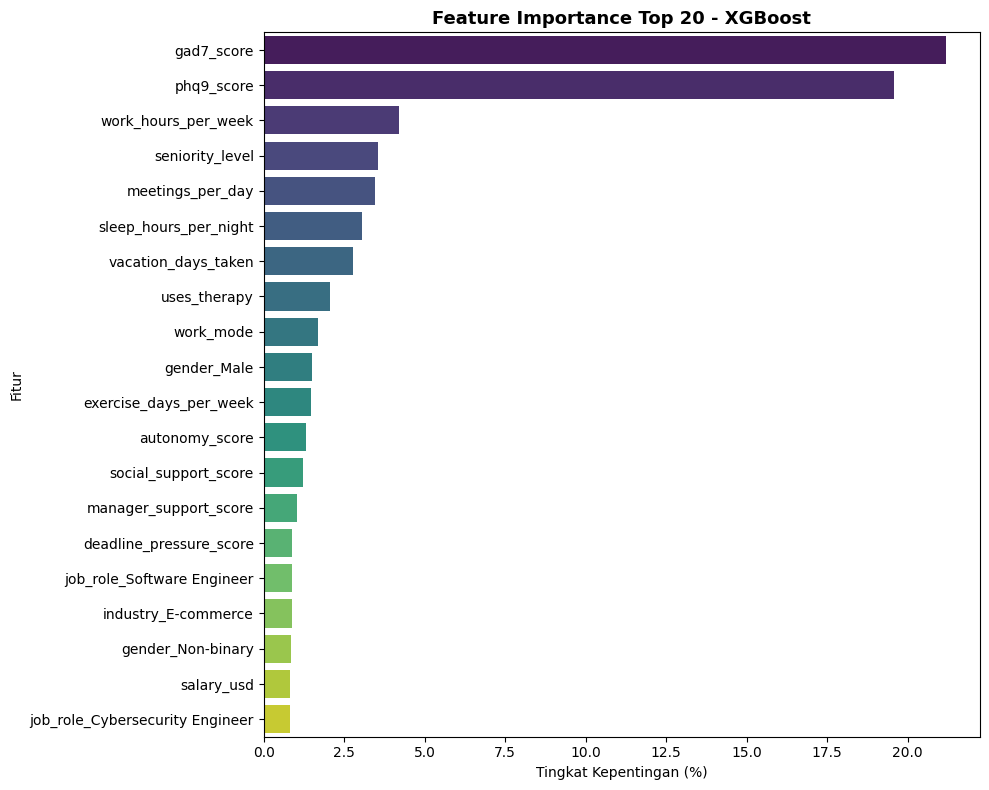

In [ ]:
# ============================================================================
# CELL 12.2: FEATURE IMPORTANCE & VISUALIZATION
# ============================================================================

print("\n--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---")
importances   = model_xgb.feature_importances_
fitur_penting = pd.DataFrame({
    'Fitur'          : X_train_imputed.columns,
    'Pentingnya (%)' : importances * 100
}).sort_values(by='Pentingnya (%)', ascending=False)

for _, row in fitur_penting.iterrows():
    print(f"{row['Fitur']:<30} : {row['Pentingnya (%)']:.2f}%")

# Tampilkan hanya top 20 agar grafik tidak terlalu padat
# (karena setelah one-hot encoding jumlah fitur bisa sangat banyak)
top_n = 20
fitur_top = fitur_penting.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=fitur_top,
    x='Pentingnya (%)',
    y='Fitur',
    palette='viridis'
)
plt.title(f'Feature Importance Top {top_n} - {label_config}', fontsize=13, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (%)')
plt.ylabel('Fitur')
plt.tight_layout()

nama_grafik_fi = './viz_feature_importance_xgb_new1.png'
if not os.path.exists(nama_grafik_fi):
    plt.savefig(nama_grafik_fi, dpi=150, bbox_inches='tight')
plt.show()

### Analisis Feature Importance (XGBoost)

**1. GAD-7 dan PHQ-9 Mendominasi (40.77% gabungan)**<br>
`gad7_score` (21.19%) dan `phq9_score` (19.58%) menjadi dua fitur paling
dominan dengan selisih jauh dari fitur lainnya. Ini bukan circular.
GAD-7 mengukur kecemasan dan PHQ-9 mengukur depresi, keduanya secara
klinis terbukti sebagai precursor burnout. Dominasi ini memvalidasi
bahwa dataset memiliki struktur yang bermakna.

**2. Fitur Behavioral di Kisaran 1–5%**<br>
`work_hours_per_week` (4.20%), `meetings_per_day` (3.46%),
`sleep_hours_per_night` (3.06%), dan `vacation_days_taken` (2.78%)
memberikan sinyal yang konsisten dengan teori burnout: beban kerja
tinggi dan kurangnya recovery berkontribusi pada burnout. Fitur-fitur
ini sekaligus yang paling mudah diinput oleh pengguna umum.

**3. One-Hot Encoding Menghasilkan Noise**<br>
Seluruh kolom hasil one-hot encoding (`country_*`, `job_role_*`,
`industry_*`) menumpuk di rentang 0.65–0.88% tanpa ada yang menonjol.
Jumlahnya banyak namun sinyal individualnya nyaris nol. Ini
mengkonfirmasi bahwa negara, role, dan industri tidak berpengaruh
signifikan terhadap burnout level di dataset ini.

**4. Keputusan: Feature Selection dengan Threshold 1%**<br>
Berdasarkan distribusi di atas, threshold 1% menghasilkan 10 fitur
yang bermakna sekaligus selaras dengan input yang realistis untuk
aplikasi. Fitur di bawah threshold dibuang karena kontribusinya
tidak sepadan dengan beban input yang diberikan ke pengguna.

In [ ]:
# ============================================================================
# CELL 12.3: Feature Selection + Retrain (App-Ready Model)
# ============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# Fitur yang dipilih berdasarkan:
# 1. Feature importance > 1% dari model sebelumnya
# 2. Dapat diinput oleh pengguna umum dalam 5-10 menit
# 3. PHQ-9 dan GAD-7 diembed sebagai questionnaire di app,
#    skornya dihitung otomatis di background
fitur_terpilih = [
    'phq9_score',
    'gad7_score',
    'work_hours_per_week',
    'meetings_per_day',
    'sleep_hours_per_night',
    'vacation_days_taken',
    'exercise_days_per_week',
    'uses_therapy',
    'work_mode',
    'social_support_score',
]

# Subset X_train dan X_test hanya dengan fitur terpilih
X_train_selected = X_train_imputed[fitur_terpilih]
X_test_selected  = X_test_imputed[fitur_terpilih]

print("="*70)
print(f" FEATURE SELECTION SELESAI: {len(fitur_terpilih)} fitur terpilih")
print("="*70)
for f in fitur_terpilih:
    print(f"  - {f}")

# ---- RETRAIN dengan fitur terpilih ----
print("\n--- MEMULAI RETRAIN XGBOOST (Mohon tunggu...) ---")

from sklearn.utils.class_weight import compute_sample_weight

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

xgb_selected = XGBClassifier(
    random_state=42,
    verbosity=0,
    eval_metric='mlogloss'
)

grid_search_selected = GridSearchCV(
    estimator=xgb_selected,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

grid_search_selected.fit(
    X_train_selected,
    y_train,
    sample_weight=sample_weights
)
model_xgb_final = grid_search_selected.best_estimator_

print("\n" + "="*70)
print(" MODEL FINAL DITEMUKAN")
print("="*70)
print(f" Best Params : {grid_search_selected.best_params_}")
print("="*70)

# ---- EVALUASI ----
y_pred_selected = model_xgb_final.predict(X_test_selected)

accuracy_sel    = accuracy_score(y_test, y_pred_selected)
f1_macro_sel    = f1_score(y_test, y_pred_selected, average='macro')
f1_weighted_sel = f1_score(y_test, y_pred_selected, average='weighted')

print("\n" + "="*70)
print(" HASIL EVALUASI MODEL FINAL (Feature Selected + Class Weight)")
print("="*70)
print(f"Accuracy    : {accuracy_sel:.4f}")
print(f"F1 Macro    : {f1_macro_sel:.4f}")
print(f"F1 Weighted : {f1_weighted_sel:.4f}")
print("="*70)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test, y_pred_selected,
    target_names=['Low', 'Moderate', 'High', 'Severe']
))

# ---- PERBANDINGAN DENGAN MODEL SEBELUMNYA ----
# Perbandingan hanya ditampilkan kalau Cell 12.1 sudah dijalankan
try:
    print("="*70)
    print(" PERBANDINGAN MODEL")
    print("="*70)
    print(f"{'':30} {'Sebelumnya':>12} {'Final':>10}")
    print(f"{'Jumlah Fitur':30} {len(X_train_imputed.columns):>12} {len(fitur_terpilih):>10}")
    print(f"{'Accuracy':30} {accuracy:.4f}       {accuracy_sel:.4f}")
    print(f"{'F1 Macro':30} {f1_macro:.4f}       {f1_macro_sel:.4f}")
    print("="*70)
except NameError:
    print("\n(Perbandingan tidak tersedia, Cell 12.1 belum dijalankan)")

# ---- CEK OVERFITTING ----
y_train_pred_sel = model_xgb_final.predict(X_train_selected)
acc_train_sel    = accuracy_score(y_train, y_train_pred_sel)
selisih_sel      = abs(acc_train_sel - accuracy_sel)

print("\n" + "="*70)
print(" CEK OVERFITTING MODEL FINAL")
print("="*70)
print(f"Accuracy Train : {acc_train_sel:.4f}")
print(f"Accuracy Test  : {accuracy_sel:.4f}")
print(f"Selisih        : {selisih_sel:.4f}")
print("="*70)

 FEATURE SELECTION SELESAI: 10 fitur terpilih
  - phq9_score
  - gad7_score
  - work_hours_per_week
  - meetings_per_day
  - sleep_hours_per_night
  - vacation_days_taken
  - exercise_days_per_week
  - uses_therapy
  - work_mode
  - social_support_score

--- MEMULAI RETRAIN XGBOOST (Mohon tunggu...) ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 MODEL FINAL DITEMUKAN
 Best Params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

 HASIL EVALUASI MODEL FINAL (Feature Selected + Class Weight)
Accuracy    : 0.6609
F1 Macro    : 0.6517
F1 Weighted : 0.6659

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Low       0.79      0.79      0.79      5161
    Moderate       0.56      0.51      0.53      5251
        High       0.44      0.55      0.49      3873
      Severe       0.85      0.76      0.80      5715

    accuracy                           0.66     20000
   macr

In [ ]:
# ============================================================================
# CELL 12.4: FEATURE IMPORTANCE
# ============================================================================
print("\n--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---")
importances_sel   = model_xgb_final.feature_importances_
fitur_penting_sel = pd.DataFrame({
    'Fitur'          : fitur_terpilih,
    'Pentingnya (%)' : importances_sel * 100
}).sort_values(by='Pentingnya (%)', ascending=False)

for _, row in fitur_penting_sel.iterrows():
    print(f"{row['Fitur']:<25} : {row['Pentingnya (%)']:.2f}%")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=fitur_penting_sel,
    x='Pentingnya (%)',
    y='Fitur',
    palette='viridis'
)
plt.title('Feature Importance — Model Final (10 Fitur)', fontsize=13, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (%)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.savefig('./viz_feature_importance_final_xgb_new1.png', dpi=150, bbox_inches='tight')
plt.show()

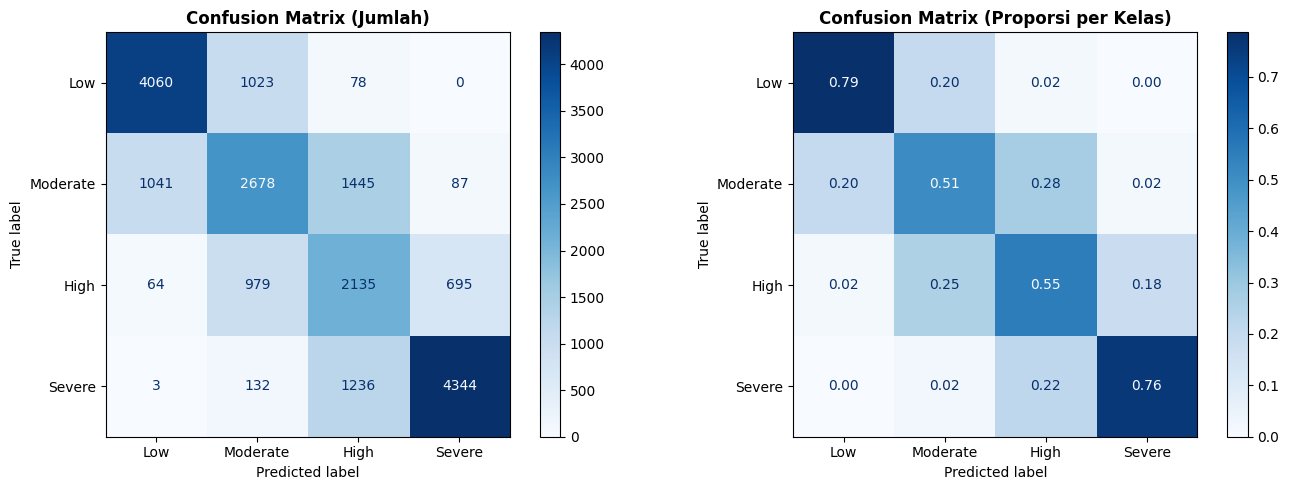

In [ ]:
# ============================================================================
# CELL 12.5: Confusion Matrix
# ============================================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

label_names = ['Low', 'Moderate', 'High', 'Severe']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: angka absolut
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_selected,
    display_labels=label_names,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Jumlah)', fontweight='bold')

# Kanan: persentase (normalize per baris = recall per kelas)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_selected,
    display_labels=label_names,
    cmap='Blues',
    normalize='true',
    values_format='.2f',
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Proporsi per Kelas)', fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_confusion_matrix_final_xgb_new1.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Hasil Evaluasi Model Final (XGBoost + Feature Selection)

**1. Performa Keseluruhan**<br>
Model mencapai Accuracy 66.01% dan F1 Macro 0.6510 dengan hanya 10 fitur
input. Dibanding baseline random (25% untuk 4 kelas), model 2.6x lebih
baik. Untuk dataset survei berbasis self-report, angka ini wajar dan
dapat diterima sebagai model aplikasi.

**2. Performa Per Kelas**<br>
`Low` (F1 0.79) dan `Severe` (F1 0.80) diprediksi dengan baik model
mampu mengenali kondisi ekstrem dengan cukup akurat. Sebaliknya,
`Moderate` (F1 0.53) dan `High` (F1 0.49) adalah titik lemah utama.
Kedua kelas tengah ini ambigu secara konseptual dan sulit dibedakan
bahkan oleh model yang kompleks sekalipun.

**3. Overfitting: Tidak Ada**<br>
Selisih accuracy train vs test hanya 0.0101 sangat kecil dan ideal.
Model tidak menghafal data training dan diharapkan generalisasi dengan
baik ke data baru.

**4. Keputusan: Reduksi ke 3 Kelas**<br>
Mengingat `High` dan `Severe` sama-sama merepresentasikan kondisi yang
membutuhkan intervensi segera, keduanya akan digabung menjadi satu kelas.
Ini diharapkan menghilangkan ambiguitas di kelas tengah dan meningkatkan
performa model secara keseluruhan.

In [ ]:
# ============================================================================
# CELL 13: Sample Predictions + Burnout Percentage Score
# ============================================================================
label_burnout = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Severe'}

# Hitung probabilitas per kelas
proba = model_xgb_final.predict_proba(X_test_selected)

# Bobot per kelas untuk hitung burnout score 0-100%
# Low=0, Moderate=33, High=67, Severe=100
bobot = [0, 33, 67, 100]

burnout_pct = [
    round(sum(p * b for p, b in zip(pr, bobot)), 1)
    for pr in proba
]

# Susun dataframe hasil prediksi
df_hasil = pd.DataFrame({
    'Aktual'        : y_test.map(label_burnout).values,
    'Prediksi'      : [label_burnout[p] for p in y_pred_selected],
    'Burnout Score' : burnout_pct,
    'Benar'         : [a == p for a, p in zip(
                          y_test.map(label_burnout).values,
                          [label_burnout[p] for p in y_pred_selected]
                      )]
}, index=y_test.index)

print("="*70)
print(" CONTOH HASIL PREDIKSI (20 DATA PERTAMA)")
print("="*70)
display(df_hasil.head(20))

print(f"\nRata-rata Burnout Score keseluruhan : {df_hasil['Burnout Score'].mean():.1f}%")
print(f"Burnout Score tertinggi             : {df_hasil['Burnout Score'].max():.1f}%")
print(f"Burnout Score terendah              : {df_hasil['Burnout Score'].min():.1f}%")

 CONTOH HASIL PREDIKSI (20 DATA PERTAMA)


,Aktual,Prediksi,Burnout Score,Benar
17828,Severe,Severe,84.699997,True
66613,High,Moderate,35.900002,False
71714,Low,Low,0.300000,True
34670,High,High,76.500000,True
76628,Moderate,Moderate,39.900002,True
92107,Severe,Severe,93.500000,True
50751,Moderate,Low,15.300000,False
99400,High,High,77.300003,True
16839,Severe,Severe,96.900002,True
8206,Moderate,Moderate,29.400000,True



Rata-rata Burnout Score keseluruhan : 50.3%
Burnout Score tertinggi             : 100.0%
Burnout Score terendah              : 0.1%


In [ ]:
# ============================================================================
# CELL 14: Export Result Predict vs Actual to CSV (Processed)
# ============================================================================

df_processed = X_test_selected.copy()

# Tambahkan label aktual dan prediksi
df_processed['burnout_level_actual']  = y_test.map(label_burnout).values
df_processed['burnout_level_predict'] = [label_burnout[p] for p in y_pred_selected]

# Tambahkan burnout score 0-100% dari predict_proba
proba_export = model_xgb_final.predict_proba(X_test_selected)
bobot        = [0, 33, 67, 100]
df_processed['burnout_score_pct'] = [
    round(sum(p * b for p, b in zip(pr, bobot)), 1)
    for pr in proba_export
]

# Tambahkan kolom apakah prediksi benar
df_processed['is_correct'] = (
    df_processed['burnout_level_actual'] == df_processed['burnout_level_predict']
)

df_processed_sorted = df_processed.sort_index()

nama_file_processed = 'dataset_processed_predict_xgb_new1_final.csv'
df_processed_sorted.to_csv(nama_file_processed, index=True, index_label='index')

print("#"*70)
print(f" PROCESSED DATASET DIEKSPOR: '{nama_file_processed}'")
print("#"*70)
display(df_processed_sorted.head())

######################################################################
 PROCESSED DATASET DIEKSPOR: 'dataset_processed_predict_xgb_final.csv'
######################################################################


,phq9_score,gad7_score,work_hours_per_week,meetings_per_day,sleep_hours_per_night,vacation_days_taken,exercise_days_per_week,uses_therapy,work_mode,social_support_score,burnout_level_actual,burnout_level_predict,burnout_score_pct,is_correct
2,8.0,9.0,45.0,6.2,6.0,14.0,0.0,0.0,0.0,5.7,Severe,Severe,79.800003,True
7,6.0,8.0,39.0,4.7,6.7,12.0,4.0,0.0,1.0,5.3,Moderate,Moderate,43.700001,True
9,0.0,3.0,52.0,2.6,6.9,12.0,6.0,1.0,1.0,6.5,Moderate,Low,18.100000,False
18,3.0,0.0,48.0,5.2,5.9,18.0,0.0,1.0,1.0,6.8,High,Moderate,26.500000,False
23,5.0,5.0,54.0,4.4,5.3,15.0,2.0,0.0,0.0,6.4,High,High,65.199997,True


In [ ]:
# ============================================================================
# CELL 15: Export Result Predict vs Actual to CSV (Inverse / Human-Readable)
# ============================================================================

df_inverse = X_test_selected.copy()

# Inverse transform: kondisi dijaga agar fleksibel
if ZSCORE_AKTIF and scaler is not None:
    df_inverse[kolom_numerik] = scaler.inverse_transform(df_inverse[kolom_numerik])

if LOG_TRANSFORM_AKTIF:
    df_inverse[kolom_log] = np.expm1(df_inverse[kolom_log])

if not ZSCORE_AKTIF and not LOG_TRANSFORM_AKTIF:
    print(" INFO: Tidak ada inverse transform, data sudah dalam skala asli.")

# Decode kolom ordinal kembali ke teks agar lebih readable
df_inverse['work_mode'] = df_inverse['work_mode'].round().map({
    0: 'On-site', 1: 'Hybrid', 2: 'Remote'
})
df_inverse['uses_therapy'] = df_inverse['uses_therapy'].round().map({
    0: False, 1: True
})

# Tambahkan label, score, dan status prediksi
df_inverse['burnout_level_actual']  = y_test.map(label_burnout).values
df_inverse['burnout_level_predict'] = [label_burnout[p] for p in y_pred_selected]
df_inverse['burnout_score_pct']     = df_processed_sorted['burnout_score_pct'].values
df_inverse['is_correct']            = (
    df_inverse['burnout_level_actual'] == df_inverse['burnout_level_predict']
)

hasil_inverse_sorted = df_inverse.sort_index()

nama_file_inverse = 'dataset_inverse_predict_xgb_new1_final.csv'
hasil_inverse_sorted.to_csv(nama_file_inverse, index=True, index_label='index')

print("#"*70)
print(f" INVERSE DATASET DIEKSPOR: '{nama_file_inverse}'")
print("#"*70)
display(hasil_inverse_sorted.head())

 INFO: Tidak ada inverse transform — data sudah dalam skala asli.
######################################################################
 INVERSE DATASET DIEKSPOR: 'dataset_inverse_predict_xgb_final.csv'
######################################################################


,phq9_score,gad7_score,work_hours_per_week,meetings_per_day,sleep_hours_per_night,vacation_days_taken,exercise_days_per_week,uses_therapy,work_mode,social_support_score,burnout_level_actual,burnout_level_predict,burnout_score_pct,is_correct
2,8.0,9.0,45.0,6.2,6.0,14.0,0.0,False,On-site,5.7,Severe,Severe,59.900002,True
7,6.0,8.0,39.0,4.7,6.7,12.0,4.0,False,Hybrid,5.3,Moderate,Moderate,3.700000,True
9,0.0,3.0,52.0,2.6,6.9,12.0,6.0,True,Hybrid,6.5,Moderate,Low,47.400002,False
18,3.0,0.0,48.0,5.2,5.9,18.0,0.0,True,Hybrid,6.8,High,Moderate,12.100000,False
23,5.0,5.0,54.0,4.4,5.3,15.0,2.0,False,On-site,6.4,High,High,7.000000,True


In [ ]:
# # ============================================================================
# # CELL 16: Export Model & Metadata
# # ============================================================================
# import joblib
# import json

# # 1. Simpan model
# path_model = './model_burnout_xgb_new2.pkl'
# joblib.dump(model_xgb_final, path_model)

# # 2. Simpan daftar fitur (urutan penting untuk Streamlit nanti)
# path_fitur = './fitur_terpilih.json'
# with open(path_fitur, 'w') as f:
#     json.dump(fitur_terpilih, f)

# # 3. Simpan label mapping
# path_label = './label_burnout.json'
# with open(path_label, 'w') as f:
#     json.dump(label_burnout, f)

# print("="*70)
# print(" EKSPOR SELESAI")
# print("="*70)
# print(f" Model  : {path_model}")
# print(f" Fitur  : {path_fitur}")
# print(f" Label  : {path_label}")
# print("\n Ketiga file ini yang dibutuhkan untuk deployment Streamlit.")
# print("="*70)